# 01 — Exploratory Data Analysis

Hard drive failures in data center infrastructure don't happen in isolation. A single failed drive degrades the RAID array it belongs to; the rebuild stresses the surviving drives; a second failure during rebuild means total data loss. Downstream: service downtime, SLA breaches, and in regulated sectors, compliance violations. The cost of downtime ranges from $1K to $100K+ per hour depending on the business.

The industry standard is reactive — replace the drive after it fails. But drives broadcast distress signals before they die: SMART (Self-Monitoring, Analysis and Reporting Technology) sensor readings that deteriorate days or weeks before the actual failure. The question is whether those signals are strong enough to build a predictive model.

Backblaze operates 300,000+ drives and publishes daily SMART readings for every one of them. The raw daily data (28M rows, ~13 GB) was too large to fit in memory with pandas, so the aggregation pipeline uses **polars** with lazy evaluation to produce **one row per drive** with statistics (last, max, mean, std, slope) per SMART attribute — see `scripts/build_drive_dataset.py`.

This notebook explores the aggregated dataset (318k drives, 32 MB): how severe is the class imbalance, which SMART attributes carry signal, and whether there are patterns across manufacturers and models.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

COLOR_HEALTHY = "#1a7f37"
COLOR_FAILURE = "#cf222e"
COLOR_NEUTRAL = "#57606a"

## 1. Load data

In [11]:
df = pd.read_parquet("../data/processed/drives.parquet")
print(f"Drives: {len(df):,}  |  Columns: {df.shape[1]}  |  Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

Drives: 318,426  |  Columns: 92  |  Memory: 282.5 MB


,serial_number,smart_1_raw_last,smart_1_raw_max,smart_1_raw_mean,smart_1_raw_std,smart_3_raw_last,smart_3_raw_max,smart_3_raw_mean,smart_3_raw_std,smart_4_raw_last,smart_4_raw_max,smart_4_raw_mean,smart_4_raw_std,smart_5_raw_last,smart_5_raw_max,smart_5_raw_mean,smart_5_raw_std,smart_7_raw_last,smart_7_raw_max,smart_7_raw_mean,smart_7_raw_std,smart_9_raw_last,smart_9_raw_max,smart_9_raw_mean,smart_9_raw_std,...,smart_199_raw_mean,smart_199_raw_std,smart_240_raw_last,smart_240_raw_max,smart_240_raw_mean,smart_240_raw_std,smart_241_raw_last,smart_241_raw_max,smart_241_raw_mean,smart_241_raw_std,smart_242_raw_last,smart_242_raw_max,smart_242_raw_mean,smart_242_raw_std,failure,capacity_bytes,model,days_observed,drive_age_days,smart_5_raw_slope,smart_187_raw_slope,smart_188_raw_slope,smart_197_raw_slope,smart_198_raw_slope,manufacturer
0,000a43e7dee60010,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,480036847616,DELLBOSS VD,90,89,0.0,0.0,0.0,0.0,0.0,Other
1,00ac486b9bec0010,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,480036847616,DELLBOSS VD,90,89,0.0,0.0,0.0,0.0,0.0,Other
2,01b776caeb6a0010,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,480036847616,DELLBOSS VD,90,89,0.0,0.0,0.0,0.0,0.0,Other
3,02308a3415be0010,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,480036847616,DELLBOSS VD,90,89,0.0,0.0,0.0,0.0,0.0,Other
4,0394cd7bc5d00010,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,480036847616,DELLBOSS VD,90,89,0.0,0.0,0.0,0.0,0.0,Other


## 2. Target distribution (class imbalance)

Healthy: 317,359  |  Failed: 1,067  |  Failure rate: 0.335%


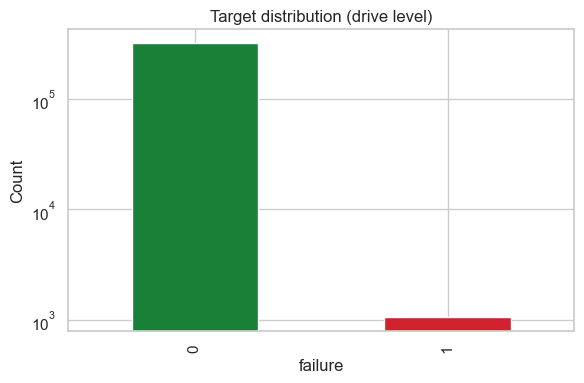

In [12]:
counts = df["failure"].value_counts()
total = len(df)
failures = counts.get(1, 0)
print(f"Healthy: {counts.get(0, 0):,}  |  Failed: {failures:,}  |  Failure rate: {failures / total * 100:.3f}%")

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot.bar(ax=ax, color=[COLOR_HEALTHY, COLOR_FAILURE])
ax.set_title("Target distribution (drive level)")
ax.set_xlabel("failure")
ax.set_ylabel("Count")
ax.set_yscale("log")
plt.tight_layout()
plt.savefig("../figures/target_distribution.png", dpi=150)
plt.show()

Only 0.3% of drives failed — the dataset is heavily imbalanced. This rules out accuracy as a metric (a model that always predicts "healthy" scores 99.7%) and means we'll need resampling or class weights during training.

## 3. Feature overview

In [13]:
print(f"Total features: {df.shape[1]}")
print(f"\nNon-numeric columns: {list(df.select_dtypes(exclude='number').columns)}")
print(f"\nNumeric columns with any nulls:")
num_cols = df.select_dtypes(include="number").columns
null_pct = (df[num_cols].isnull().mean() * 100).sort_values(ascending=False)
print(null_pct[null_pct > 0] if (null_pct > 0).any() else "  None — all filled")
print(f"\nBasic stats:")
df.describe().T[["mean", "std", "min", "max"]].head(20)

Total features: 92

Non-numeric columns: ['serial_number', 'model', 'manufacturer']

Numeric columns with any nulls:
  None — all filled

Basic stats:


,mean,std,min,max
smart_1_raw_last,4.169839e+07,7.146102e+07,0.0,4.294967e+09
smart_1_raw_max,8.249808e+07,1.147278e+08,0.0,4.294967e+09
smart_1_raw_mean,4.167765e+07,5.848553e+07,0.0,4.294967e+09
smart_1_raw_std,2.409329e+07,3.350063e+07,0.0,2.408409e+08
smart_3_raw_last,2.571572e+03,3.593715e+03,0.0,1.097300e+04
smart_3_raw_max,2.576618e+03,3.599904e+03,0.0,1.104300e+04
smart_3_raw_mean,2.568898e+03,3.591425e+03,0.0,1.099273e+04
smart_3_raw_std,5.383497e+00,6.890139e+01,0.0,2.891901e+03
smart_4_raw_last,1.504987e+01,1.089671e+02,0.0,2.518700e+04
smart_4_raw_max,1.505099e+01,1.089681e+02,0.0,2.518700e+04


92 numeric features, no remaining nulls (filled with 0 during aggregation). The non-numeric columns (`serial_number`, `model`, `manufacturer`) will be dropped or encoded before modeling.

## 4. Failure rate by drive model

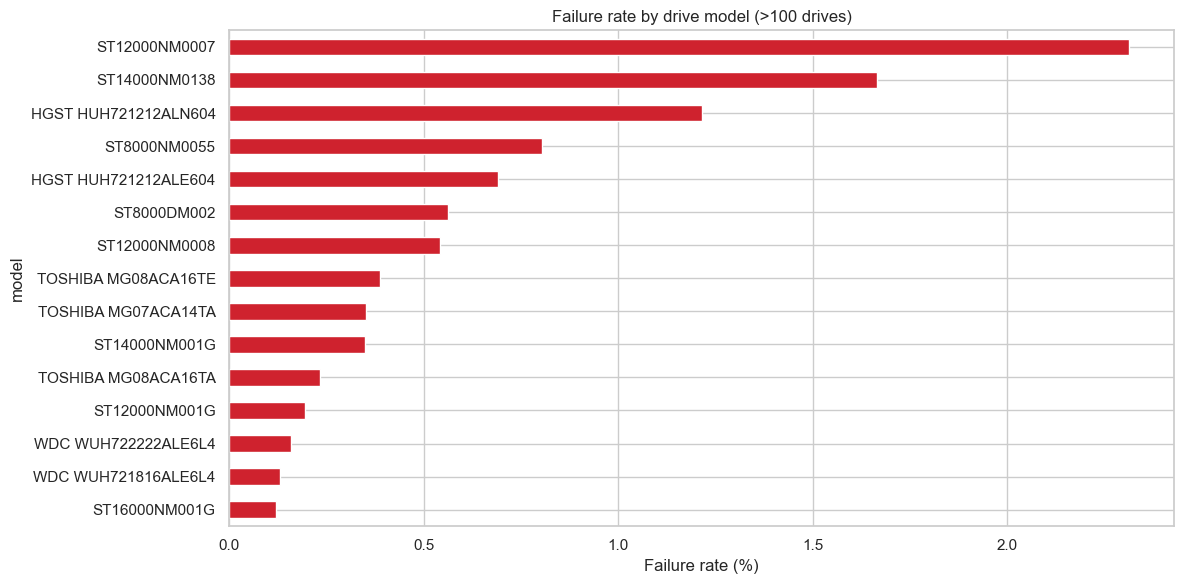

In [14]:
model_stats = (
    df.groupby("model")
    .agg(total=("failure", "count"), failures=("failure", "sum"))
    .assign(failure_rate=lambda x: x["failures"] / x["total"] * 100)
    .sort_values("failures", ascending=False)
)

top_models = model_stats[model_stats["total"] > 100].head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_models["failure_rate"].sort_values().plot.barh(ax=ax, color=COLOR_FAILURE)
ax.set_title("Failure rate by drive model (>100 drives)")
ax.set_xlabel("Failure rate (%)")
plt.tight_layout()
plt.savefig("../figures/failure_rate_by_model.png", dpi=150)
plt.show()

Failure rates vary widely across models — some fail 10x more than others. The drive model is worth including as a feature (via manufacturer grouping to avoid high cardinality).

## 5. Correlation: aggregated features vs failure

Top 20 features correlated with failure:
smart_5_raw_max        0.242475
smart_5_raw_std        0.234604
smart_5_raw_last       0.220228
days_observed         -0.196938
drive_age_days        -0.194745
smart_9_raw_std       -0.166850
smart_5_raw_mean       0.155577
smart_188_raw_slope    0.118560
smart_197_raw_mean     0.099441
smart_188_raw_std      0.094815
smart_197_raw_max      0.088302
smart_197_raw_last     0.087461
smart_198_raw_mean     0.084580
smart_5_raw_slope      0.083292
smart_198_raw_max      0.079008
smart_187_raw_max      0.078829
smart_187_raw_last     0.078813
smart_198_raw_last     0.078436
smart_197_raw_std      0.071678
smart_187_raw_std      0.065699
dtype: float64


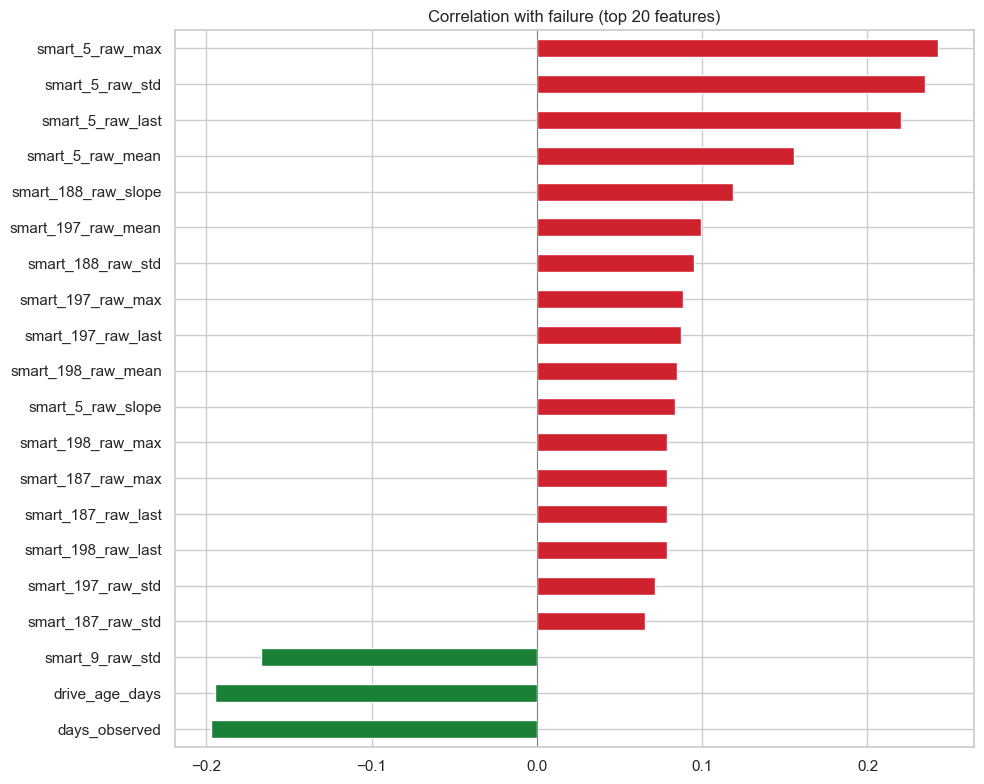

In [15]:
num_cols = df.select_dtypes(include="number").columns.drop("failure")
corr_with_failure = df[num_cols].corrwith(df["failure"]).sort_values(key=abs, ascending=False)

print("Top 20 features correlated with failure:")
print(corr_with_failure.head(20))

fig, ax = plt.subplots(figsize=(10, 8))
top_corr = corr_with_failure.head(20)
colors = [COLOR_FAILURE if v > 0 else COLOR_HEALTHY for v in top_corr.sort_values().values]
top_corr.sort_values().plot.barh(ax=ax, color=colors)
ax.set_title("Correlation with failure (top 20 features)")
ax.axvline(0, color=COLOR_NEUTRAL, linewidth=0.5)
plt.tight_layout()
plt.savefig("../figures/feature_correlation.png", dpi=150)
plt.show()

SMART 5 (reallocated sectors) and 197 (pending sectors) dominate the top correlations — both in their max and slope variants. Features we engineered during aggregation (slope, std) appear alongside raw values, confirming that the trend matters as much as the absolute reading.

## 6. Critical SMART attributes: healthy vs failed drives

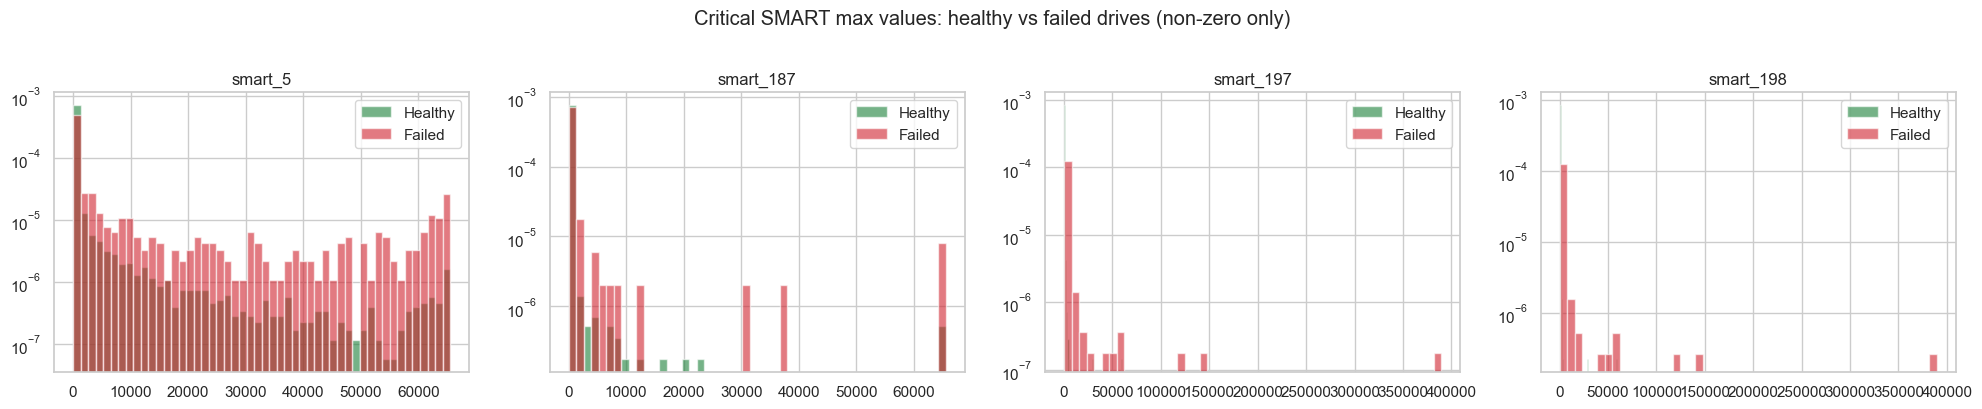

In [16]:
critical = ["smart_5_raw_max", "smart_187_raw_max", "smart_197_raw_max", "smart_198_raw_max"]
critical_present = [c for c in critical if c in df.columns]

fig, axes = plt.subplots(1, len(critical_present), figsize=(5 * len(critical_present), 4))
if len(critical_present) == 1:
    axes = [axes]

for ax, col in zip(axes, critical_present):
    for label, color, name in [(0, COLOR_HEALTHY, "Healthy"), (1, COLOR_FAILURE, "Failed")]:
        subset = df[df["failure"] == label][col].dropna()
        subset = subset[subset > 0]
        if len(subset) > 0:
            ax.hist(subset, bins=50, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(col.replace("_raw_max", ""))
    ax.set_yscale("log")
    ax.legend()

plt.suptitle("Critical SMART max values: healthy vs failed drives (non-zero only)", y=1.02)
plt.tight_layout()
plt.savefig("../figures/critical_smart_distributions.png", dpi=150)
plt.show()

## 7. Failure rate by manufacturer

               total  failures  failure_rate
manufacturer                                
HGST           31832       226      0.709977
Seagate       110736       436      0.393729
Toshiba       101176       282      0.278722
WDC            73208       123      0.168014
Other           1474         0      0.000000


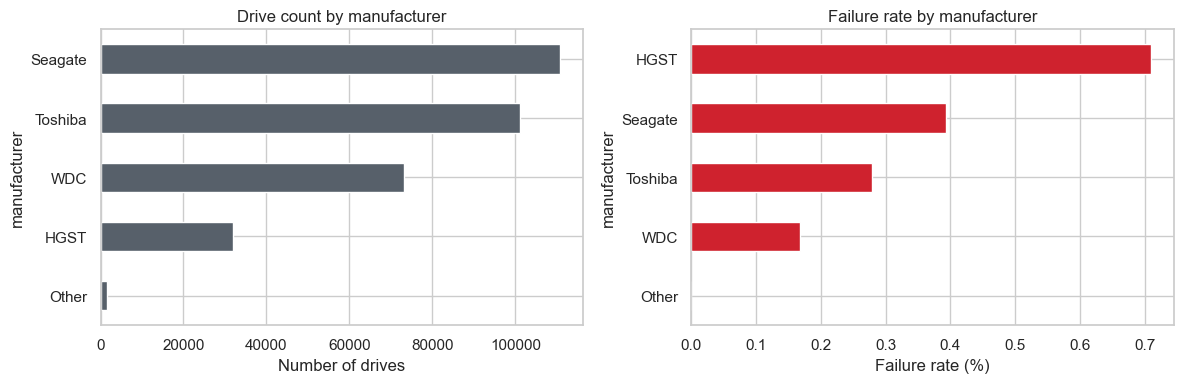

In [17]:
mfr_stats = (
    df.groupby("manufacturer")
    .agg(total=("failure", "count"), failures=("failure", "sum"))
    .assign(failure_rate=lambda x: x["failures"] / x["total"] * 100)
    .sort_values("failure_rate", ascending=False)
)
print(mfr_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mfr_stats["total"].sort_values().plot.barh(ax=axes[0], color=COLOR_NEUTRAL)
axes[0].set_title("Drive count by manufacturer")
axes[0].set_xlabel("Number of drives")

mfr_stats["failure_rate"].sort_values().plot.barh(ax=axes[1], color=COLOR_FAILURE)
axes[1].set_title("Failure rate by manufacturer")
axes[1].set_xlabel("Failure rate (%)")

plt.tight_layout()
plt.savefig("../figures/manufacturer_stats.png", dpi=150)
plt.show()

Manufacturer is a useful grouping — it captures hardware design differences without the high cardinality of individual model names.

## 8. SMART slopes: degradation trends in failed vs healthy drives

Failed drives show steeper slopes — their SMART values are deteriorating faster over time. This validates the aggregation strategy: capturing the rate of change, not just the snapshot, adds predictive signal that a single day's reading would miss.

## Summary

Key takeaways from EDA:
- **Class imbalance**: ~99.7% healthy, ~0.3% failures — accuracy is useless, need F1/AUC-ROC and class balancing techniques
- **Aggregation works**: 28M daily rows → 318k drive-level rows (32 MB), keeping all signal
- **Top signals**: SMART 5, 187, 197, 198 (max and slope variants) show the strongest correlation with failure
- **Slopes matter**: failed drives show steeper degradation trends — the rate of change is as predictive as the absolute value
- **Manufacturer matters**: failure rates vary across manufacturers, worth including as a feature

Next step: feature selection and model training in `03_modeling.ipynb`.

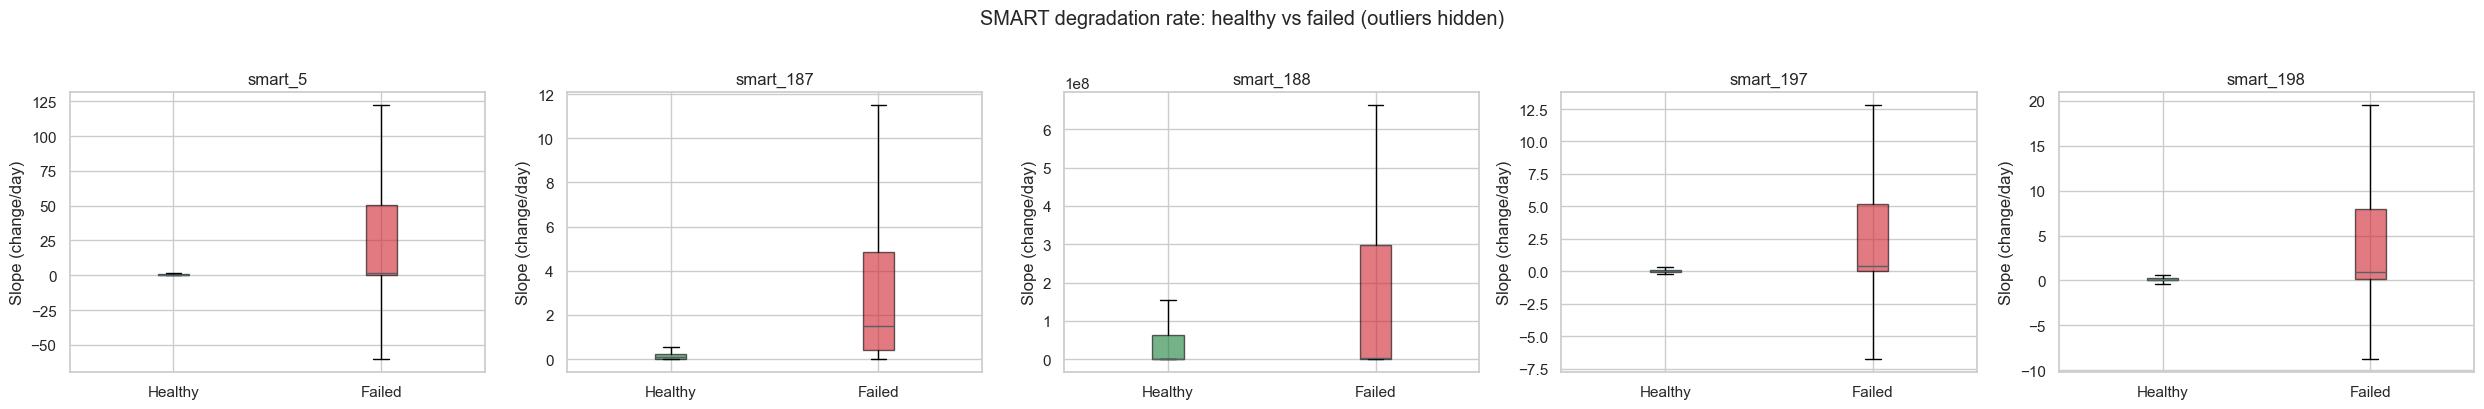

In [18]:
slope_cols = [c for c in df.columns if c.endswith("_slope")]

if slope_cols:
    fig, axes = plt.subplots(1, len(slope_cols), figsize=(5 * len(slope_cols), 4))
    if len(slope_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, slope_cols):
        healthy = df[df["failure"] == 0][col]
        failed = df[df["failure"] == 1][col]
        bp = ax.boxplot(
            [healthy[healthy != 0], failed[failed != 0]],
            tick_labels=["Healthy", "Failed"],
            showfliers=False,
            patch_artist=True,
        )
        bp["boxes"][0].set_facecolor(COLOR_HEALTHY)
        bp["boxes"][0].set_alpha(0.6)
        bp["boxes"][1].set_facecolor(COLOR_FAILURE)
        bp["boxes"][1].set_alpha(0.6)
        for median in bp["medians"]:
            median.set_color(COLOR_NEUTRAL)
        ax.set_title(col.replace("_raw_slope", ""))
        ax.set_ylabel("Slope (change/day)")

    plt.suptitle("SMART degradation rate: healthy vs failed (outliers hidden)", y=1.02)
    plt.tight_layout()
    plt.savefig("../figures/smart_slopes.png", dpi=150)
    plt.show()
else:
    print("No slope columns found")